**Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=4, suppress=True)
print('Libraries loaded.')

Libraries loaded.


**Plot style settings**

In [2]:
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
sns.set_palette('husl')

**Load the dataset**

In [3]:
df = pd.read_csv("student_performance.csv")
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


**Check data types and non-null counts**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


**Statistical summary**

In [5]:
df.describe().round(3)

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000
mean,500000.500,15.029,84.711,5.985,84.284
std,288675.279,6.899,9.424,1.956,15.433
min,1.000,0.000,50.000,0.000,9.400
25%,250000.750,10.300,78.300,4.700,73.900
50%,500000.500,15.000,85.000,6.000,87.500
75%,750000.250,19.700,91.800,7.300,100.000
max,1000000.000,40.000,100.000,10.000,100.000


**Missing value check**

In [6]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing.to_string())
print()
print(f'Total missing values: {missing.sum()}')

Missing values per column:
student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0

Total missing values: 0


**Key statistics for the study hours column**

In [7]:
print('Insights:')
print(f'  - Average weekly self-study hours : {df["weekly_self_study_hours"].mean():.2f}')
print(f'  - Study hours range                : {df["weekly_self_study_hours"].min():.1f} -> {df["weekly_self_study_hours"].max():.1f}')
print(f'  - Average total score               : {df["total_score"].mean():.2f}')
print(f'  - Total score std deviation         : {df["total_score"].std():.2f}')

Insights:
  - Average weekly self-study hours : 15.03
  - Study hours range                : 0.0 -> 40.0
  - Average total score               : 84.28
  - Total score std deviation         : 15.43


**Outlier check (IQR method) on the numeric columns used for modeling**

In [8]:
cols_for_outliers = ['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']

print('IQR outlier analysis:')
for col in cols_for_outliers:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'  {col:24s} | IQR={IQR:.2f} | [{lower:.2f}, {upper:.2f}] | {len(outliers):,} outliers ({len(outliers)/len(df)*100:.2f}%)')

IQR outlier analysis:
  weekly_self_study_hours  | IQR=9.40 | [-3.80, 33.80] | 3,541 outliers (0.35%)
  attendance_percentage    | IQR=13.50 | [58.05, 112.05] | 3,518 outliers (0.35%)
  class_participation      | IQR=2.60 | [0.80, 11.20] | 4,927 outliers (0.49%)
  total_score              | IQR=26.10 | [34.75, 139.15] | 2,027 outliers (0.20%)


**Distribution plots**

*(The dataset has 1,000,000 rows — plots below sample a subset for speed.)*

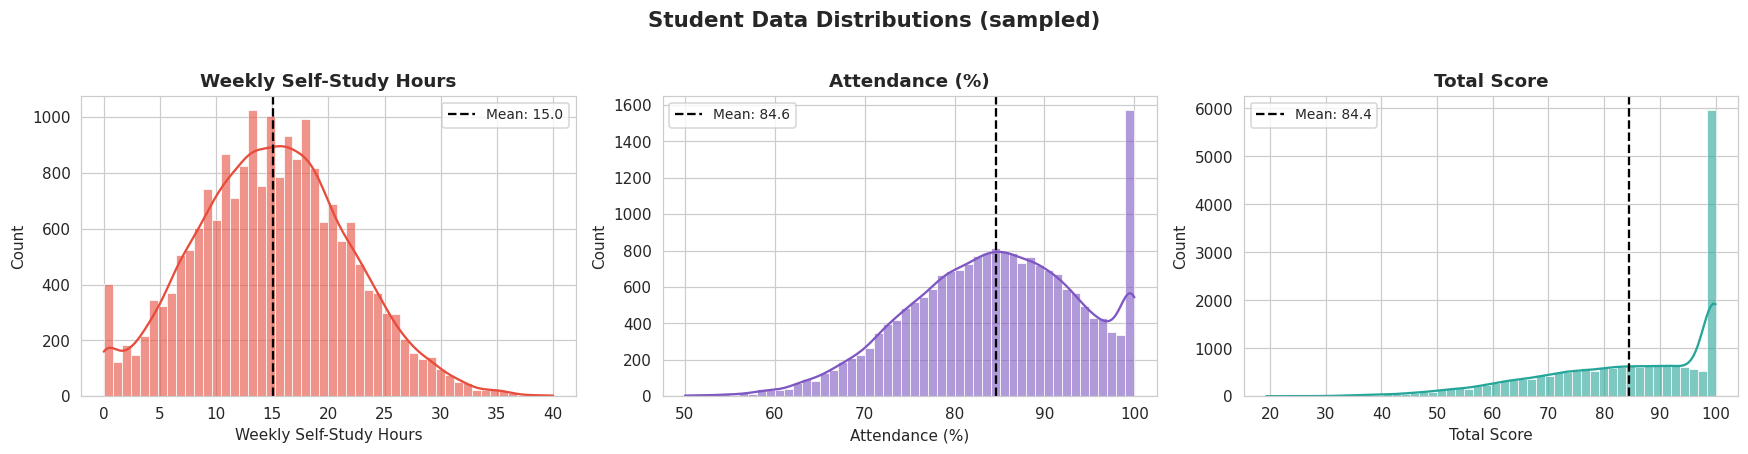

In [17]:
SAMPLE_SIZE = 20000
sample = df.sample(SAMPLE_SIZE, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Student Data Distributions (sampled)', fontsize=14, fontweight='bold', y=1.02)

vars_info = [
    ('weekly_self_study_hours', '#e74c3c', 'Weekly Self-Study Hours'),
    ('attendance_percentage',   '#7E57C2', 'Attendance (%)'),
    ('total_score',             '#26A69A', 'Total Score'),
]

for ax, (col, color, label) in zip(axes, vars_info):
    sns.histplot(sample[col], bins=50, kde=True, color=color, alpha=0.6, ax=ax)
    mean_val = sample[col].mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Correlation analysis and scatter plots**

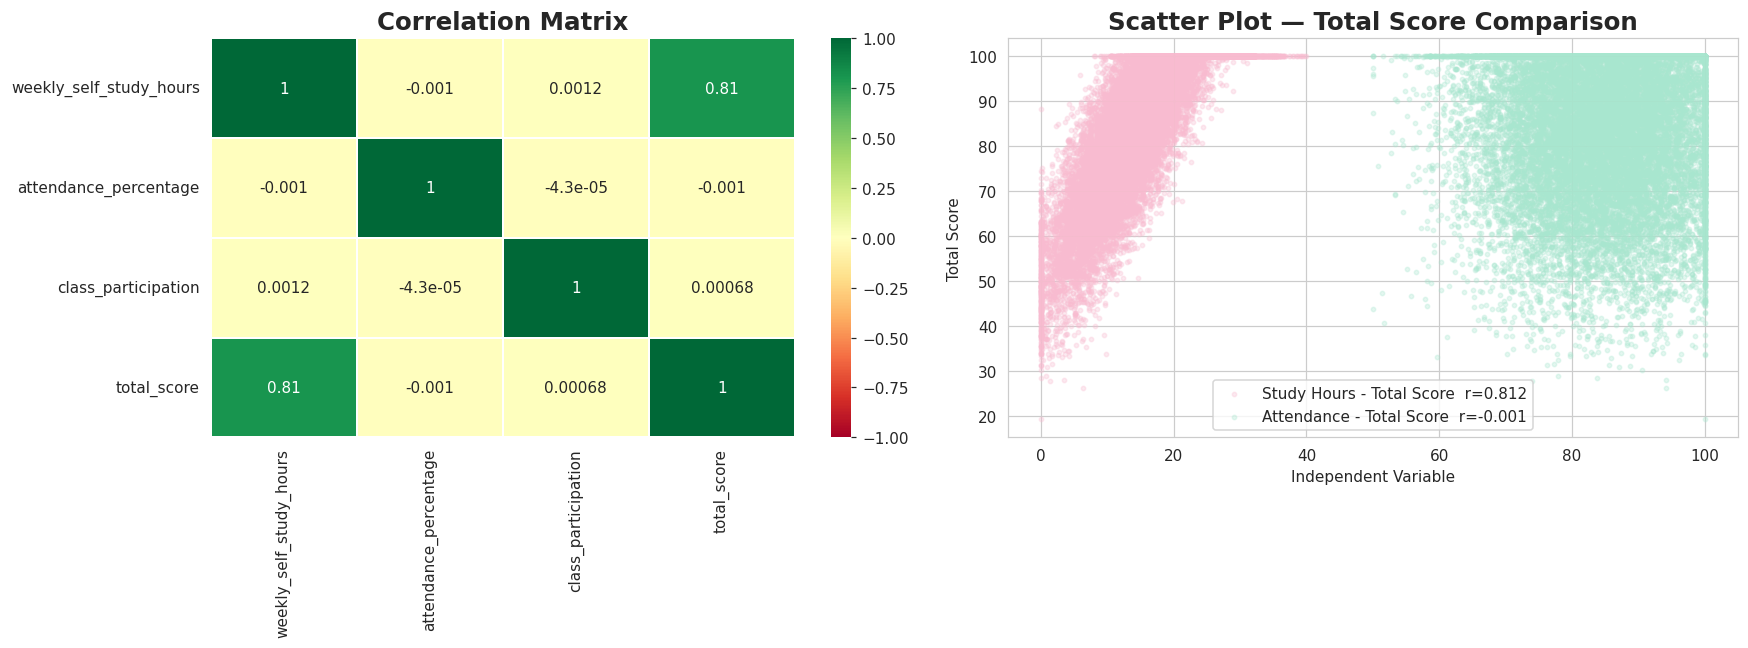

Study hours - Total score correlation : r = 0.812
Attendance  - Total score correlation : r = -0.001


In [10]:
corr_matrix = df[['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']].corr()

r_hours = corr_matrix.loc['weekly_self_study_hours', 'total_score']
r_att   = corr_matrix.loc['attendance_percentage', 'total_score']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, linewidths=1, ax=axes[0])
axes[0].set_title('Correlation Matrix', fontsize=16, fontweight='bold')

axes[1].scatter(sample['weekly_self_study_hours'], sample['total_score'],
                color='#F8BBD0', alpha=0.3, s=8, label=f'Study Hours - Total Score  r={r_hours:.3f}')
axes[1].scatter(sample['attendance_percentage'], sample['total_score'],
                color='#A8E6CF', alpha=0.3, s=8, label=f'Attendance - Total Score  r={r_att:.3f}')
axes[1].set_title('Scatter Plot — Total Score Comparison', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Independent Variable')
axes[1].set_ylabel('Total Score')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Study hours - Total score correlation : r = {r_hours:.3f}')
print(f'Attendance  - Total score correlation : r = {r_att:.3f}')

**Boxplot — study hours, attendance, participation, total score**

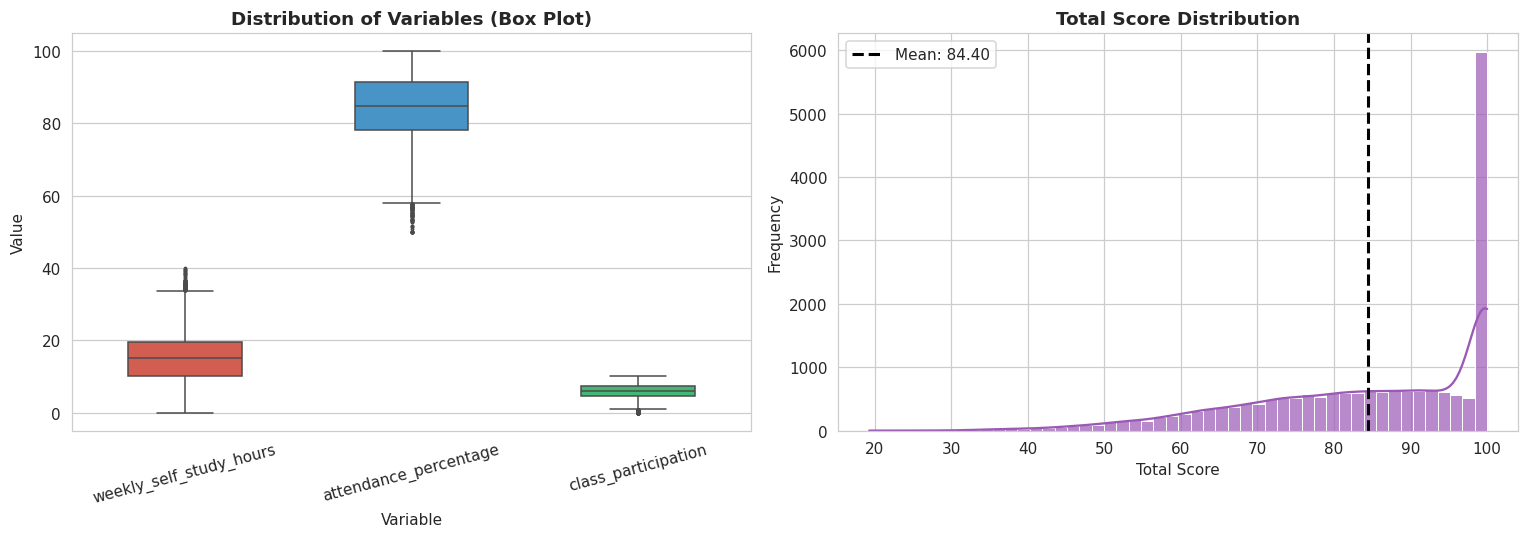

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

melted = sample[['weekly_self_study_hours', 'attendance_percentage', 'class_participation']].melt(
    var_name='Variable', value_name='Value')
sns.boxplot(x='Variable', y='Value', data=melted,
            palette=['#e74c3c', '#3498db', '#2ecc71'], width=0.5, fliersize=1.5, ax=axes[0])
axes[0].set_title('Distribution of Variables (Box Plot)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

sns.histplot(sample['total_score'], bins=50, kde=True, color='#9b59b6', alpha=0.7, ax=axes[1])
axes[1].axvline(sample['total_score'].mean(), color='black', linestyle='--', linewidth=2,
                label=f'Mean: {sample["total_score"].mean():.2f}')
axes[1].set_xlabel('Total Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Total Score Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## Polynomial Regression Model

*(Predicting total_score from weekly_self_study_hours, the strongest predictor.)*

**Train/test split**

In [12]:
X = df[['weekly_self_study_hours']].values
y = df['total_score'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")

Training set: 800,000 samples
Test set:     200,000 samples


**Train polynomial models of different degrees and compare R² / RMSE**

In [13]:
degrees = [1, 2, 3, 4, 5]
results = []
models = {}

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    models[degree] = model

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results.append({
        'Degree': degree,
        'Train R2': round(r2_score(y_train, y_train_pred), 4),
        'Test R2': round(r2_score(y_test, y_test_pred), 4),
        'Test RMSE': round(mean_squared_error(y_test, y_test_pred) ** 0.5, 4),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 Degree  Train R2  Test R2  Test RMSE
      1    0.6597   0.6600     8.9964
      2    0.7123   0.7127     8.2703
      3    0.7152   0.7157     8.2269
      4    0.7169   0.7174     8.2022
      5    0.7171   0.7176     8.1988


**Pick the best degree and plot the fit**

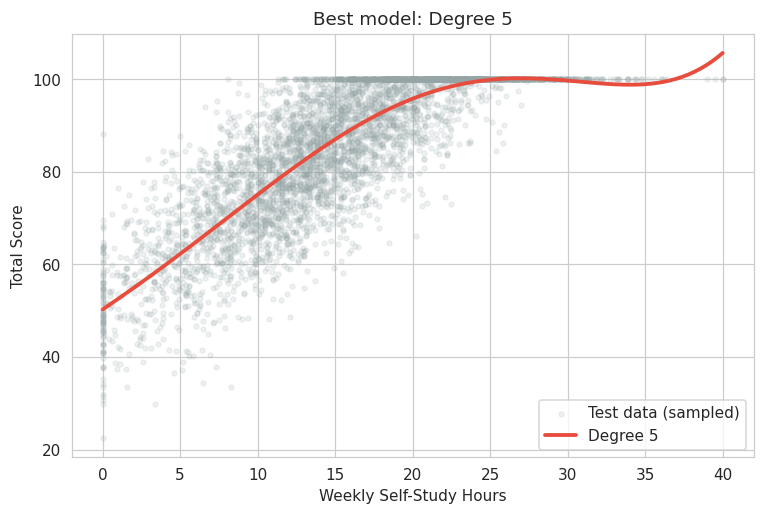

Best degree: 5
Test R2: 0.7176
Test RMSE: 8.1988


In [14]:
best_degree = int(results_df.loc[results_df['Test R2'].idxmax(), 'Degree'])
best_model = models[best_degree]

X_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
test_sample_idx = np.random.choice(len(X_test), 5000, replace=False)

plt.figure(figsize=(8, 5))
plt.scatter(X_test[test_sample_idx], y_test[test_sample_idx], alpha=0.15, s=10, color='#95a5a6', label='Test data (sampled)')
plt.plot(X_line, best_model.predict(X_line), color='#e74c3c', linewidth=2.5, label=f'Degree {best_degree}')
plt.xlabel('Weekly Self-Study Hours')
plt.ylabel('Total Score')
plt.title(f'Best model: Degree {best_degree}')
plt.legend()
plt.show()

print(f"Best degree: {best_degree}")
print(f"Test R2: {results_df.loc[results_df['Degree']==best_degree, 'Test R2'].values[0]}")
print(f"Test RMSE: {results_df.loc[results_df['Degree']==best_degree, 'Test RMSE'].values[0]}")

## Second Scenario: Attendance → Total Score

*(Attendance had almost no correlation with total_score — let's see what the model finds.)*

In [15]:
X2 = df[['attendance_percentage']].values
y2 = df['total_score'].values

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

model2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)

r2_att = r2_score(y2_test, y2_pred)
rmse_att = mean_squared_error(y2_test, y2_pred) ** 0.5

print(f"Test R2 (attendance -> total_score): {r2_att:.4f}")
print(f"Test RMSE: {rmse_att:.4f}")
print()
print("As expected from the near-zero correlation, attendance is a poor predictor of total_score on its own.")

Test R2 (attendance -> total_score): -0.0000
Test RMSE: 15.4298

As expected from the near-zero correlation, attendance is a poor predictor of total_score on its own.
